# 03 - Ingeniería de variables prudente para predicción de AKI

## Objetivo
Evaluar de forma prudente si el dataset limpio requería nuevas variables derivadas antes de pasar a la construcción final del conjunto de modelado. Dado que la cohorte disponible es relativamente pequeña y presenta un fuerte desbalanceo en la variable objetivo, se evitó una estrategia de ingeniería de variables agresiva. En su lugar, se priorizó la revisión de redundancias y la creación exclusiva de variables simples, clínicamente interpretables y metodológicamente defendibles.

### 1. Importar librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set(style="whitegrid")

FIGURES_DIR = "../figures"
RESULTS_DIR = "../results"

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("Carpetas de figures y results listas.")

Carpetas de figures y results listas.


### 2. Carga del dataset limpio 
Se cargó el archivo `aki_dataset_clean.csv` generado en el notebook anterior desde la carpeta `data/processed/`.

In [2]:
file_path = "../data/processed/aki_dataset_clean.csv"

df = pd.read_csv(file_path)

print("Dataset limpio cargado correctamente.")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Dataset limpio cargado correctamente.
Filas: 1175
Columnas: 13


### 3. Revisión rápida del dataset 

In [3]:
df.head()

,Sexo,EdadAproxIngreso,Creatinina_mg_dL,Potasio_mmol_L,Sodio_mmol_L,BaselineCreatinina,AINE,IECA,ARAII,DIURETICO,VANCOMICINA,AMINOGLUCOSIDO,AKI_48h
0,0,61,0.96,4.83,144.0,0.96,0,0,0,0,0,0,0
1,0,46,1.15,4.41,142.0,1.15,0,0,0,0,0,0,0
2,1,25,0.75,4.09,138.0,0.75,1,0,0,0,0,0,0
3,0,78,0.97,4.70,143.0,0.97,0,0,0,0,0,0,0
4,1,35,0.63,4.43,140.0,0.63,0,0,0,0,0,0,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sexo                1175 non-null   int64  
 1   EdadAproxIngreso    1175 non-null   int64  
 2   Creatinina_mg_dL    1170 non-null   float64
 3   Potasio_mmol_L      1122 non-null   float64
 4   Sodio_mmol_L        1126 non-null   float64
 5   BaselineCreatinina  1173 non-null   float64
 6   AINE                1175 non-null   int64  
 7   IECA                1175 non-null   int64  
 8   ARAII               1175 non-null   int64  
 9   DIURETICO           1175 non-null   int64  
 10  VANCOMICINA         1175 non-null   int64  
 11  AMINOGLUCOSIDO      1175 non-null   int64  
 12  AKI_48h             1175 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 119.5 KB


In [5]:
missing_summary = pd.DataFrame({
    "n_missing": df.isnull().sum(),
    "percent_missing": (df.isnull().mean() * 100).round(2)
}).sort_values(by="percent_missing", ascending=False)

missing_summary

,n_missing,percent_missing
Potasio_mmol_L,53,4.51
Sodio_mmol_L,49,4.17
Creatinina_mg_dL,5,0.43
BaselineCreatinina,2,0.17
Sexo,0,0.00
EdadAproxIngreso,0,0.00
AINE,0,0.00
IECA,0,0.00
ARAII,0,0.00
DIURETICO,0,0.00


### 4. Identificación de variables numéricas y binarias 
Se clasificaron las variables del dataset en dos grandes grupos:
- variables numéricas continuas
- variables binarias

Las variables numéricas incluyeron:
- `EdadAproxIngreso`,
- `Creatinina_mg_dL`,
- `Potasio_mmol_L`,
- `Sodio_mmol_L`,
- `BaselineCreatinina`.

Las variables binarias incluyeron:
- `Sexo`,
- `AINE`,
- `IECA`,
- `ARAII`,
- `DIURETICO`,
- `VANCOMICINA`,
- `AMINOGLUCOSIDO`,
- `AKI_48h`.

Esta clasificación fue necesaria para organizar el análisis posterior y decidir qué relaciones podían explorarse mediante correlación y qué variables podían combinarse en nuevas características derivadas.


In [6]:
numeric_cols = [
    "EdadAproxIngreso",
    "Creatinina_mg_dL",
    "Potasio_mmol_L",
    "Sodio_mmol_L",
    "BaselineCreatinina"
]

binary_cols = [
    "Sexo",
    "AINE",
    "IECA",
    "ARAII",
    "DIURETICO",
    "VANCOMICINA",
    "AMINOGLUCOSIDO",
    "AKI_48h"
]

### 5. Revisión de correlación entre variables númericas
Se calculó una matriz de correlación entre las variables numéricas y la variable objetivo `AKI_48h`, representándola mediante un mapa de calor.

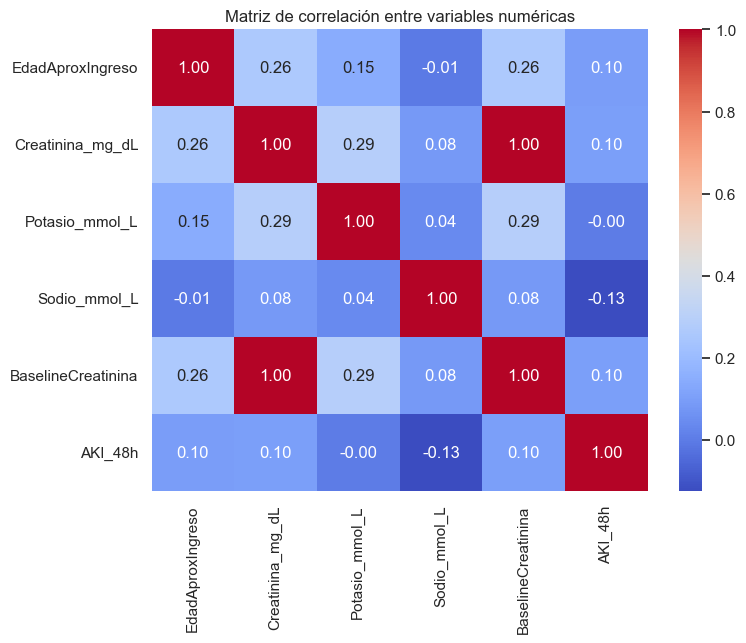

In [7]:
corr = df[numeric_cols + ["AKI_48h"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables numéricas")
plt.show()

El resultado más importante de esta sección fue la correlación observada entre:
- `Creatinina_mg_dL`
- `BaselineCreatinina`

La correlación entre ambas fue **1.00**, lo que indica una relación lineal prácticamente perfecta.

#### Interpretación metodológica
Este hallazgo sugiere una redundancia extrema entre ambas variables. Esto significa que ambas columnas están aportando casi exactamente la misma información al modelo. Mantener simultáneamente dos variables tan solapadas puede:
- no aportar valor predictivo adicional,
- dificultar la interpretación del modelo,
- e introducir redundancia innecesaria en el conjunto final de predictores.

#### Otras observaciones
El resto de correlaciones fueron moderadas o bajas:
- `EdadAproxIngreso` mostró una correlación débil positiva con `Creatinina_mg_dL` y `BaselineCreatinina` (~0.26),
- `Potasio_mmol_L` mostró correlaciones bajas a moderadas con creatinina (~0.29),
- `Sodio_mmol_L` presentó correlaciones muy bajas con el resto,
- `AKI_48h` mostró correlaciones débiles con todas las variables numéricas.

Esto es esperable en un problema clínico complejo, donde el desenlace suele depender de múltiples factores y no de una sola asociación lineal fuerte.

### 6. Comparación directa entre `Creatinina_mg_dL` y `BaselineCreatinina`
Dado el resultado de la matriz de correlación, se realizó una comparación específica entre ambas variables.

#### 6.1. Visualización conjunta
Se construyó un gráfico de dispersión entre `Creatinina_mg_dL` y `BaselineCreatinina` para observar visualmente el grado de coincidencia entre ambas. La representación confirmó que los puntos se alineaban prácticamente sobre la diagonal, lo que es consistente con una equivalencia casi total.

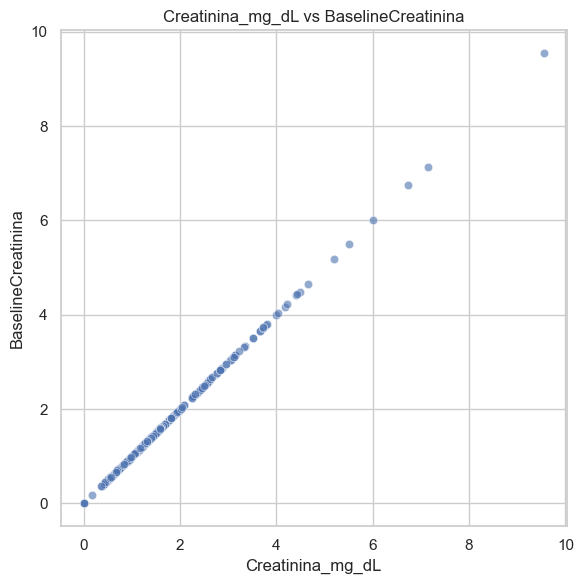

In [8]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=df, x="Creatinina_mg_dL", y="BaselineCreatinina", alpha=0.6)
plt.title("Creatinina_mg_dL vs BaselineCreatinina")
plt.xlabel("Creatinina_mg_dL")
plt.ylabel("BaselineCreatinina")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_03_creatinina_vs_baseline.png", dpi=300, bbox_inches="tight")
plt.show()

#### 6.2. Diferencia absoluta entre ambas
Se creó la variable auxiliar `Diff_Creatininas`, definida como la diferencia absoluta entre `Creatinina_mg_dL` y `BaselineCreatinina`. Esta variable permitió medir de forma directa el grado de discrepancia entre ambas columnas en cada observación.


In [9]:
df["Diff_Creatininas"] = (df["Creatinina_mg_dL"] - df["BaselineCreatinina"]).abs()

df["Diff_Creatininas"].describe()

count    1170.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: Diff_Creatininas, dtype: float64

#### 6.3. Cuántas filas tienen exactamente el mismo valor
Se calculó el número y porcentaje de filas en las que ambas variables tenían exactamente el mismo valor. 

In [10]:
same_value_mask = df["Creatinina_mg_dL"] == df["BaselineCreatinina"]

print("Filas con valores exactamente iguales:", same_value_mask.sum())
print("Porcentaje de igualdad exacta:", round(same_value_mask.mean() * 100, 2), "%")

Filas con valores exactamente iguales: 1170
Porcentaje de igualdad exacta: 99.57 %


#### Interpretación
Este resultado confirma de forma muy sólida que `Creatinina_mg_dL` y `BaselineCreatinina` son, en la práctica, casi la misma variable para esta cohorte. La existencia de solo una pequeña fracción de casos no idénticos no cambia la conclusión general: existe una redundancia muy alta.

### 6.4. Distribución de la diferencia

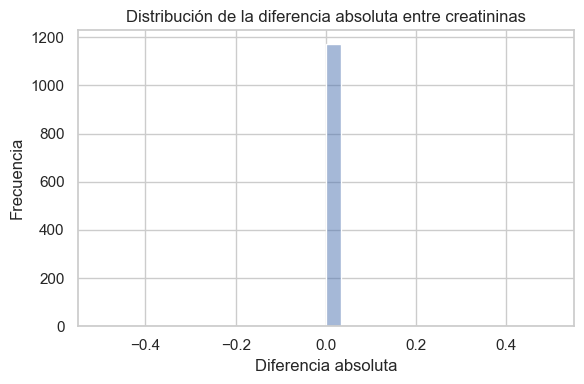

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(df["Diff_Creatininas"], bins=30, kde=True)
plt.title("Distribución de la diferencia absoluta entre creatininas")
plt.xlabel("Diferencia absoluta")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_04_diff_creatininas.png", dpi=300, bbox_inches="tight")
plt.show()

#### Evaluación de redundancia entre creatininas

Se analiza la relación entre `Creatinina_mg_dL` y `BaselineCreatinina` para determinar si ambas variables aportan información diferenciada o si resultan prácticamente equivalentes. Esta decisión es importante para evitar redundancia innecesaria en el modelo final.

### 7. Revisión de distribución de edad y decisión sobre una variable derivada clínica
Se revisó la distribución de `EdadAproxIngreso` mediante estadísticos descriptivos y un histograma. A partir de esta variable, se creó la nueva característica binaria `Edad_ge_65`, que identifica si el paciente tenía 65 años o más en el momento del ingreso.

In [12]:
df["EdadAproxIngreso"].describe()

count    1175.000000
mean       71.823830
std        19.510285
min         1.000000
25%        63.000000
50%        76.000000
75%        86.000000
max       110.000000
Name: EdadAproxIngreso, dtype: float64

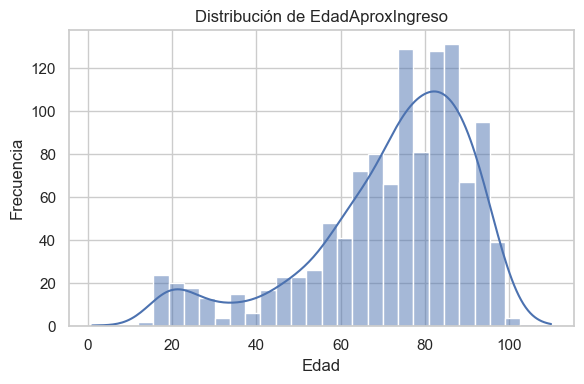

In [13]:
plt.figure(figsize=(6, 4))
sns.histplot(df["EdadAproxIngreso"], bins=30, kde=True)
plt.title("Distribución de EdadAproxIngreso")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_05_edad_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

#### Crear variable binaria `Edad_ge_65`

In [14]:
df["Edad_ge_65"] = (df["EdadAproxIngreso"] >= 65).astype(int)

print(df["Edad_ge_65"].value_counts(dropna=False))

Edad_ge_65
1    851
0    324
Name: count, dtype: int64


#### Creación de la variable Edad_ge_65

Se genera una variable binaria que identifica ingresos correspondientes a pacientes de 65 años o más. Esta variable se incorpora por su posible relevancia clínica y por tratarse de una transformación simple, interpretable y ampliamente utilizada en contextos sanitarios.

### 8. Creación de una variable agregada de exposición farmacológica
#### 8.1. Definir fármacos de interés
Se definió un conjunto de fármacos potencialmente relacionados con riesgo renal:

In [15]:
drug_cols = [
    "AINE",
    "IECA",
    "ARAII",
    "DIURETICO",
    "VANCOMICINA",
    "AMINOGLUCOSIDO"
]

#### 8.2. Crear conteo de exposiciones
A partir de estas variables binarias se creó una nueva variable denominada `N_Farmacos_Riesgo`, calculada como la suma por fila del número de exposiciones registradas.

In [16]:
df["N_Farmacos_Riesgo"] = df[drug_cols].sum(axis=1)

df["N_Farmacos_Riesgo"].value_counts().sort_index()

N_Farmacos_Riesgo
0    225
1    679
2    233
3     38
Name: count, dtype: int64

#### 8.3. Visualizar distribución

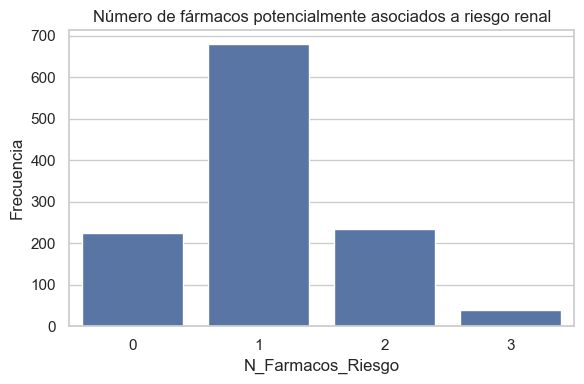

In [17]:
plt.figure(figsize=(6, 4))
sns.countplot(x="N_Farmacos_Riesgo", data=df)
plt.title("Número de fármacos potencialmente asociados a riesgo renal")
plt.xlabel("N_Farmacos_Riesgo")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig_06_n_farmacos_riesgo.png", dpi=300, bbox_inches="tight")
plt.show()

#### Creación de la variable N_Farmacos_Riesgo

Se construye una variable agregada que representa el número total de exposiciones farmacológicas potencialmente relacionadas con riesgo renal registradas en cada ingreso. Esta variable resume de forma sencilla la carga farmacológica potencialmente nefrotóxica y mantiene una interpretación clínica razonable.

### 9. Revisión de las nuevas variables frente al outcome
Se exploró de forma descriptiva la relación entre:
- `Edad_ge_65` y `AKI_48h`,
- `N_Farmacos_Riesgo` y `AKI_48h`.

Para ello se utilizaron tablas cruzadas normalizadas por fila.

#### 9.1. Edad_ge_65 vs AKI_48h

In [18]:
pd.crosstab(df["Edad_ge_65"], df["AKI_48h"], normalize="index") * 100

AKI_48h,0,1
Edad_ge_65,,
0,99.382716,0.617284
1,96.827262,3.172738


#### 9.2. N_Farmacos_Riesgo vs AKI_48h

In [19]:
pd.crosstab(df["N_Farmacos_Riesgo"], df["AKI_48h"], normalize="index") * 100

AKI_48h,0,1
N_Farmacos_Riesgo,,
0,99.111111,0.888889
1,98.379971,1.620029
2,93.562232,6.437768
3,97.368421,2.631579


### 10. Decisión provisional sobre las variables de creatinina
#### Decisión provisional sobre Creatinina_mg_dL y BaselineCreatinina
En esta fase no se eliminó ninguna de las dos variables relacionadas con creatinina del dataset enriquecido. Sin embargo, se dejó documentada una decisión provisional importante: la redundancia observada entre `Creatinina_mg_dL` y `BaselineCreatinina` es suficientemente alta como para justificar una simplificación posterior.

La decisión definitiva se pospuso al notebook siguiente, dedicado a la construcción del dataset final de modelado, con el fin de:
- mantener trazabilidad en el proceso,
- dejar evidencia explícita del análisis realizado,
- y tomar la decisión final de forma deliberada y documentada.

Metodológicamente, esta fue una decisión prudente, ya que permitió separar claramente la fase de análisis exploratorio de redundancias de la fase de definición final del conjunto de entrada al modelo.

### 11. Creación del dataset enriquecido
Se generó un nuevo DataFrame, `df_fe`, que conservó:
- las variables limpias del notebook 02,
- las variables derivadas creadas en este notebook,
- y la variable auxiliar `Diff_Creatininas` para análisis.



In [20]:
df_fe = df.copy()

print("Dimensiones del dataset con feature engineering prudente:")
print(df_fe.shape)

df_fe.head()

Dimensiones del dataset con feature engineering prudente:
(1175, 16)


,Sexo,EdadAproxIngreso,Creatinina_mg_dL,Potasio_mmol_L,Sodio_mmol_L,BaselineCreatinina,AINE,IECA,ARAII,DIURETICO,VANCOMICINA,AMINOGLUCOSIDO,AKI_48h,Diff_Creatininas,Edad_ge_65,N_Farmacos_Riesgo
0,0,61,0.96,4.83,144.0,0.96,0,0,0,0,0,0,0,0.0,0,0
1,0,46,1.15,4.41,142.0,1.15,0,0,0,0,0,0,0,0.0,0,0
2,1,25,0.75,4.09,138.0,0.75,1,0,0,0,0,0,0,0.0,0,1
3,0,78,0.97,4.70,143.0,0.97,0,0,0,0,0,0,0,0.0,1,0
4,1,35,0.63,4.43,140.0,0.63,0,0,0,0,0,0,0,0.0,0,0


### 12. Revisión final del dataset enriquecido
Se revisó la estructura final del DataFrame enriquecido mediante `info()` y `describe()`. Esta comprobación permitió verificar que:
- las nuevas variables se habían añadido correctamente,
- el número de observaciones se mantenía constante,
- y el dataset seguía siendo compacto, interpretable y técnicamente manejable.


In [21]:
df_fe.info()
df_fe.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 1175 entries, 0 to 1174
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sexo                1175 non-null   int64  
 1   EdadAproxIngreso    1175 non-null   int64  
 2   Creatinina_mg_dL    1170 non-null   float64
 3   Potasio_mmol_L      1122 non-null   float64
 4   Sodio_mmol_L        1126 non-null   float64
 5   BaselineCreatinina  1173 non-null   float64
 6   AINE                1175 non-null   int64  
 7   IECA                1175 non-null   int64  
 8   ARAII               1175 non-null   int64  
 9   DIURETICO           1175 non-null   int64  
 10  VANCOMICINA         1175 non-null   int64  
 11  AMINOGLUCOSIDO      1175 non-null   int64  
 12  AKI_48h             1175 non-null   int64  
 13  Diff_Creatininas    1170 non-null   float64
 14  Edad_ge_65          1175 non-null   int64  
 15  N_Farmacos_Riesgo   1175 non-null   int64  
dtypes: float64(5), in

,count,mean,std,min,25%,50%,75%,max
Sexo,1175.0,0.551489,0.497554,0.0,0.0,1.000,1.00,1.00
EdadAproxIngreso,1175.0,71.823830,19.510285,1.0,63.0,76.000,86.00,110.00
Creatinina_mg_dL,1170.0,1.072846,0.719258,0.0,0.7,0.885,1.18,9.55
Potasio_mmol_L,1122.0,4.289929,0.624424,0.0,3.9,4.200,4.60,7.90
Sodio_mmol_L,1126.0,138.693872,6.664357,0.0,137.0,139.000,141.00,169.00
BaselineCreatinina,1173.0,1.072805,0.718568,0.0,0.7,0.880,1.18,9.55
AINE,1175.0,0.489362,0.500100,0.0,0.0,0.000,1.00,1.00
IECA,1175.0,0.085957,0.280421,0.0,0.0,0.000,0.00,1.00
ARAII,1175.0,0.067234,0.250534,0.0,0.0,0.000,0.00,1.00
DIURETICO,1175.0,0.401702,0.490451,0.0,0.0,0.000,1.00,1.00


### 13. Guardado del dataset enriquecido
El dataset resultante se almacenó en la carpeta `data/processed/` con el nombre `aki_dataset_fe.csv`.

In [23]:
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "aki_dataset_fe.csv")

df_fe.to_csv(output_path, index=False)

print(f"Dataset enriquecido guardado en: {output_path}")

Dataset enriquecido guardado en: ../data/processed\aki_dataset_fe.csv


In [22]:
pd.DataFrame({
    "Filas_iguales_exactas": [same_value_mask.sum()],
    "Porcentaje_igualdad_exacta": [round(same_value_mask.mean() * 100, 2)]
}).to_csv(f"{RESULTS_DIR}/results_03_creatinina_redundancy_summary.csv", index=False)

df[["Diff_Creatininas"]].describe().T.to_csv(f"{RESULTS_DIR}/results_03_diff_creatininas_summary.csv")

### 14. Conclusiones del notebook 

#### Conclusiones del feature engineering prudente

En este notebook se realizó una fase conservadora de ingeniería de variables sobre el dataset limpio previamente construido.

Las principales acciones fueron:

- revisión de correlación entre variables numéricas,
- confirmación de redundancia total entre `Creatinina_mg_dL` y `BaselineCreatinina`,
- creación de una variable binaria de edad avanzada (`Edad_ge_65`),
- creación de una variable agregada de exposición farmacológica (`N_Farmacos_Riesgo`),
- mantenimiento de un enfoque prudente, evitando la creación excesiva de variables derivadas.

Como resultado, se obtuvo un dataset ligeramente enriquecido, pero todavía interpretable y metodológicamente controlado, preparado para la siguiente fase de definición del dataset final de modelado.